<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/galaxy_NGC_6975.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Galaxy NGC 6975**

[NGC 6975](https://en.m.wikipedia.org/wiki/NGC_6975) also known as NGC 6976, is a spiral galaxy in the constellation Aquarius.

https://skyserver.sdss.org/dr18/VisualTools/navi/

In [ ]:
!pip install astropy astroquery lightkurve -q
from astroquery.ned import Ned
import astropy.units as u
import matplotlib.pyplot as plt

**Load Data manually from SDSS**

Loading galaxy data from:
* https://skyserver.sdss.org/dr18/VisualTools/explore/summary?name=NGC%206975&ra=313.1084419845900&dec=-05.7723173124500
* https://skyserver.sdss.org/dr18/VisualTools/explore/fitsimg?id=1237652935641858730&spec=&apid=&fieldId=0x112d06c9a0270000&ra=313.108952897284&dec=-5.77174594873709&plateId=&mangaid=

Vailable data:
* u: Ultraviolet band (centered at approximately 354 nm)
* g: Green band (centered at approximately 477 nm)
* r: Red band (centered at approximately 623 nm)
* i: Near-infrared band (centered at approximately 762 nm)
* z: Another infrared band, further in wavelength than i (centered at approximately 913 nm)

We load u data, that is ultraviolett

In [ ]:
!wget https://raw.githubusercontent.com/deltorobarba/astrophysics/master/file-u-001737-5-0039.fits
!wget https://raw.githubusercontent.com/deltorobarba/astrophysics/master/file-z-001737-5-0039.fits

--2024-10-27 16:07:51--  https://raw.githubusercontent.com/deltorobarba/astrophysics/master/file-u-001737-5-0039.fits
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12447360 (12M) [application/octet-stream]
Saving to: ‘file-u-001737-5-0039.fits.1’

file-u-001737-5-003 100%[===================>]  11.87M  --.-KB/s    in 0.09s   

2024-10-27 16:07:52 (135 MB/s) - ‘file-u-001737-5-0039.fits.1’ saved [12447360/12447360]

--2024-10-27 16:07:52--  https://raw.githubusercontent.com/deltorobarba/astrophysics/master/file-z-001737-5-0039.fits
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP

In [ ]:
# Specify the path to the FITS file

#fits_file = './file-u-001737-5-0039.fits'
fits_file = './file-z-001737-5-0039.fits'

# Open the FITS file
hdul = fits.open(fits_file)

In [ ]:
# Print the file information
hdul.info()

Filename: ./file-z-001737-5-0039.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      85   (2048, 1489)   float32   
  1                1 ImageHDU         6   (2048,)   float32   
  2                1 BinTableHDU     27   1R x 3C   [49152E, 2048E, 1489E]   
  3                1 BinTableHDU     79   1R x 31C   [J, 3A, J, A, D, D, 2J, J, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, E, E]   


In [ ]:
# Access the primary hdul[0] data (if available)
primary_data = hdul[0].data
print(primary_data)  # Will print the data array if it exists (might be large)

[[ 0.00778961  0.10070801  0.09143066 ... -0.00173187 -0.01112366
  -0.06750488]
 [-0.01080322  0.01708984  0.05426025 ... -0.00172997 -0.03930664
   0.07336426]
 [-0.03869629  0.02639771 -0.06652832 ... -0.00172997  0.02642822
  -0.01112366]
 ...
 [ 0.01748657 -0.03826904 -0.001091   ... -0.04821777  0.00811768
  -0.02944946]
 [ 0.01748657 -0.0289917   0.00820923 ... -0.05761719  0.01751709
   0.01751709]
 [-0.06616211 -0.001091    0.08251953 ... -0.03881836 -0.02005005
   0.00811768]]


In [ ]:
header = hdulist[0].header

# Print some information from the header
print(f"Telescope: {header['TELESCOP']}")
print(f"MJD: {header['MJD']}")

In [ ]:
# Access the primary hdul[1] data (if available)
primary_data = hdul[1].data
print(primary_data)  # Will print the data array if it exists (might be large)

[0.0092946  0.00929551 0.00929638 ... 0.00938903 0.00939098 0.00939293]


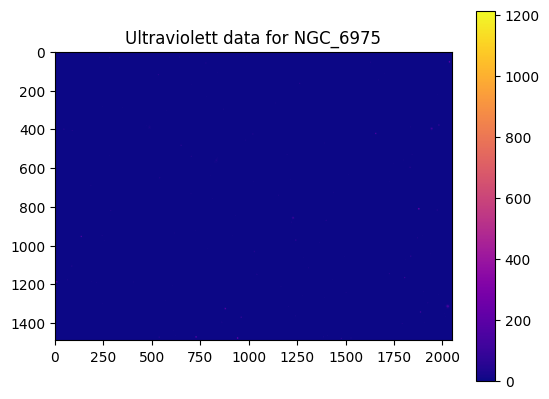

In [ ]:
plt.imshow(hdul[0].data[:, :], cmap='plasma', aspect='equal')
plt.colorbar()
plt.title("Ultraviolett data for NGC_6975")
plt.show()

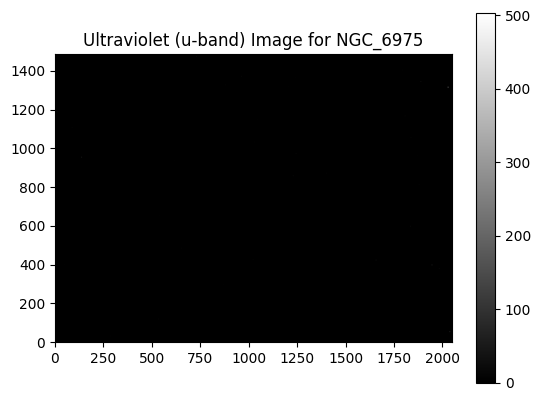

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt

# Open the FITS file
with fits.open('./file-u-001737-5-0039.fits') as hdul:
    # Display the primary image data
    image_data = hdul[0].data
    plt.imshow(image_data, cmap='gray', origin='lower')
    plt.colorbar()
    plt.title("Ultraviolet (u-band) Image for NGC_6975")
    plt.show()

**Search for details and load data automatically**

In [ ]:
# Get dec and ra details for sdss query
from astroquery.simbad import Simbad

# Query SIMBAD for information about galaxy, eg Orion Nebula M42
result_table = Simbad.query_object('NGC 6975')

# Print the results
print( result_table)

 MAIN_ID        RA           DEC      ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                                    
--------- ------------- ------------- ... -------------- ------------------- ----------------
NGC  6976 20 52 26.0260 -05 46 20.342 ...              O 2020yCat.1350....0G                1


In [ ]:
# Extract RA and DEC in h:m:s and d:m:s formats
# Convert Right Ascension (RA) and Declination (DEC) to decimal degree
ra_hms = result_table['RA'][0]
dec_dms = result_table['DEC'][0]

print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

# If you need RA and DEC in degrees, you can convert them using astropy
from astropy.coordinates import SkyCoord

# Convert RA and DEC to degrees
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
ra_deg = coord.ra.deg
dec_deg = coord.dec.deg

print("RA in degrees:", ra_deg)
print("DEC in degrees:", dec_deg)

 MAIN_ID        RA           DEC      ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
             "h:m:s"       "d:m:s"    ...                                                    
--------- ------------- ------------- ... -------------- ------------------- ----------------
NGC  6976 20 52 26.0260 -05 46 20.342 ...              O 2020yCat.1350....0G                1
RA (h:m:s): 20 52 26.0260
DEC (d:m:s): -05 46 20.342
RA in degrees: 313.10844166666664
DEC in degrees: -5.772317222222222


In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords

# Coordinates for the target object, e.g., NGC 6975
position = coords.SkyCoord(ra_deg, dec_deg, unit="deg")

# Query for images in all bands
images = SDSS.get_images(coordinates=position, band=['u', 'g', 'r', 'i', 'z'])

# Check if any images were returned
if images is None:
    print("No images found for the specified coordinates.")
else:
    # Save images to FITS files
    for img, band in zip(images, ['u', 'g', 'r', 'i', 'z']):
        img[0].writeto(f"ngc6975_{band}.fits", overwrite=True)
    print("Images saved successfully.")


No images found for the specified coordinates.


In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords

# Coordinates of NGC 6975
position = coords.SkyCoord(ra_deg, dec_deg, unit="deg")

# Query SDSS for spectral data with a specified radius
query = SDSS.query_region(position, radius='0.02 deg', spectro=True)

# Check if any results were returned
if query is None:
    print("No spectral data found for the specified coordinates.")
else:
    # Extract the first 'plate' and 'fiberID' as integers
    plate = int(query['plate'][0])
    fiberID = int(query['fiberID'][0])

    print(f"Plate = {plate}, FiberID = {fiberID}")

Plate = 636, FiberID = 396


In [ ]:
from astroquery.sdss import SDSS
from astropy.io import fits

# Specify the plate and fiber ID of the spectrum you want
plate = 636  # Replace with a valid plate number if different
fiberID = 396  # Replace with a valid fiber ID if different

# Retrieve the spectrum
sp = SDSS.get_spectra(plate=plate, fiberID=fiberID)

# Check if any spectra were returned
if sp is None:
    print("No spectrum found for the specified plate and fiber ID.")
else:
    # Access the HDUList (it's a list containing one element)
    hdulist = sp[0]

    # Save the FITS file (optional)
    hdulist.writeto('sdss_spectrum.fits', overwrite=True)

    # Access the spectral data and header
    data = hdulist[0].data
    header = hdulist[0].header

    # Print some information from the header
    print(f"Telescope: {header['TELESCOP']}")
    print(f"MJD: {header['MJD']}")


Telescope: SDSS 2.5-M
MJD: 52176


In [ ]:
from astropy.io import fits

# Open the FITS file
hdul = fits.open('sdss_spectrum.fits')

# Print the file information
hdul.info()

Filename: sdss_spectrum.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     145   ()      
  1  COADD         1 BinTableHDU     26   3840R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   
  4  B2-00010996-00010999-00011000    1 BinTableHDU    146   2047R x 7C   [E, E, E, J, E, E, E]   
  5  B2-00010997-00010999-00011000    1 BinTableHDU    146   2047

In [ ]:
#  Access the primary HDU (Header/Data Unit) to get the data
primary_hdu = hdul[0]
data = primary_hdu.data

# Display the header to learn more about the file
print(primary_hdu.header)

print(repr(hdul[1].header))  # Science data HDU header

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  TAI     =        4507976306.20 / 1st row - Number of seconds since Nov 17 1858  RA      =            313.75414 / 1st row - Right ascension of telescope boresighDEC     =           -6.306119  / 1st row - Declination of telescope boresight (dEQUINOX =              2000.00 /                                                RADECSYS= 'FK5     '           /                                                TAIHMS  = '03:43:50.33'        / 1st row - TAI time (HH:MM:SS.SS) (TAI-UT = apprTIMESYS = 'tai     '           / TAI, not UTC                                   MJD     =                52176 / MJD of observation                             MJDLIST = '52175 52176'        /        

In [ ]:
header = hdulist[0].header

# Print some information from the header
print(f"Telescope: {header['TELESCOP']}")
print(f"MJD: {header['MJD']}")

In [ ]:
# Access the primary hdul[0] data (if available)
print(hdul[0].data)  # Will print the data array if it exists (might be large)

None


**Cross-check data**

In [ ]:
# Perform an individual object cross-ID with SDSS

from astroquery.sdss import SDSS
from astropy import coordinates as coords

pos = coords.SkyCoord('0h8m05.63s +14d50m23.3s', frame='icrs')
xid = SDSS.query_region(pos, radius='5 arcsec', spectro=True)
print(xid)

If we’d like to download spectra and/or images for our match, we have all the information we need in the elements of “xid” from the above example.

In [ ]:
sp = SDSS.get_spectra(matches=xid)
im = SDSS.get_images(matches=xid, band='g')

In [ ]:
from astroquery.sdss import SDSS
print(SDSS.AVAILABLE_TEMPLATES)

In [ ]:
template = SDSS.get_spectral_template('qso')
template

In [ ]:
from astroquery.sdss import SDSS

# Get the spectral template (this part is the same as your code)
template = SDSS.get_spectral_template('qso')

# Access the HDUList object (since it's a list of one element)
hdulist = template[0]

# Explore the HDUList
for i, hdu in enumerate(hdulist):
    print(f"HDU {i}: {hdu.name}, type: {type(hdu)}")

# Access data in specific HDUs
# Example: if the data you need is in the first HDU
data = hdulist[0].data
header = hdulist[0].header


In [ ]:
from astroquery.sdss import SDSS
result = SDSS.query_photoobj(run=5714, camcol=6)
print(result[:5])

**Load and Visualize Data**

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS file
hdul = fits.open('sdss_spectrum.fits')

# Display the data from the SPZLINE extension as a table
data = hdul[3].data  # Access the SPZLINE table data

# Example: Plot the first two columns of the SPZLINE table
# Adjust the column names based on your data
plt.figure(figsize=(10, 6))
plt.plot(data['col1'], data['col2'], 'o')  # Replace 'col1' and 'col2' with actual column names
plt.xlabel('Column 1')
plt.ylabel('Column 2')
plt.title("Plot of SPZLINE Table Data")
plt.show()

# Close the FITS file
hdul.close()


KeyError: "Key 'col1' does not exist."

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Display hdul[3].data
plt.imshow(hdul[3].data[:, :], cmap='plasma', aspect='equal')
plt.colorbar()
plt.title("128x128 Slice (hdul[3])")
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

**Other Stuff (to be processed)**

In [ ]:
# Query NED for information about NGC 6975
result_table = Ned.query_object('NGC 6975')
print(result_table)

No. Object Name     RA        DEC     ... Positions Redshift Points Diameter Points Associations
                 degrees    degrees   ...                                                       
--- ----------- ---------- ---------- ... --------- --------------- --------------- ------------
  1    NGC 6975  313.10848   -5.77217 ...        15              17              14            1


In [ ]:
# Get redshift data
redshift = Ned.get_table('NGC 6975', table='redshifts')
print(redshift)

No. Frequency Targeted ...            Comments          
                       ...                              
--- ------------------ ... -----------------------------
  0                    ...                              
  1                    ...                              
  2              21-cm ... 'Quality' Fair.  Nancay data.
  3                    ...                              
  4                    ...                              
  5            Optical ...                              
  6            Optical ...      From 1993ApL&C..29....1H
  7   Optical features ...                              
  8      Optical lines ...                              
  9            Optical ...      From 1993ApL&C..29....1H
 10                    ...                              
 11                    ...                              
 12                    ...                              
 13                    ...                            SN
 14                    ...     

In [ ]:
from astropy import coordinates
from astropy import units as u

# Define coordinates of NGC 6975
coords = coordinates.SkyCoord('20h52m26.023s -05d46m19.84s', unit=(u.hourangle, u.deg))
print(coords)

<SkyCoord (ICRS): (ra, dec) in deg
    (313.10842917, -5.77217778)>


In [ ]:
# Get photometry data
photometry = Ned.get_table('NGC 6975', table='photometry')
print(photometry)

No. ...
    ...
--- ...
  1 ...
  2 ...
  3 ...
  4 ...
  5 ...
  6 ...
  7 ...
  8 ...
  9 ...
... ...
 67 ...
 68 ...
 69 ...
 70 ...
 71 ...
 72 ...
 73 ...
 74 ...
 75 ...
 76 ...
Length = 76 rows
